# 📦 Part 1 — ERA5 Big Data Ingestion & MapReduce Processing

**Dataset**: ERA5 Reanalysis 2024–2025 (~11 GB total)

**Outputs**: `climate_weekly.parquet`, `flunet_clean.parquet`, `data_profile.json`

In [1]:
!pip install pyspark netCDF4 xarray geopandas pyarrow matplotlib -q
!pip install h5netcdf cfgrib eccodes -q
!pip install h5netcdf h5py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.5/91.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 92.3 MB/s eta 0:00:00


In [2]:
import os, warnings, json, math, hashlib
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from shapely.geometry import Point
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
warnings.filterwarnings('ignore')

ERA5_FILES = [
    '/kaggle/input/era5-weather-2024-2025/era5_weather_2024.nc',
    '/kaggle/input/era5-weather-2024-2025/era5_weather_2025.nc',
]
FLUNET_CSV = '/kaggle/input/flunet-dataset/VIW_FNT.csv'
OUTPUT_DIR = '/kaggle/working/'

# ── Spark config tối ưu cho Kaggle (32GB RAM) ──────────────────
import os as _os
_N_CORES = int(_os.cpu_count() or 2)           # tự detect cores — Kaggle thường 2 hoặc 4
_DRIVER_MEM = '12g'                             # để 20GB cho xarray/pandas/OS
_SHUFFLE_PARTS = max(4, _N_CORES * 2)          # adaptive theo số core

spark = (
    SparkSession.builder
    .appName('FluSpread-ERA5-Ingestion')
    .master(f'local[{_N_CORES}]')              # dùng hết cores có sẵn
    .config('spark.driver.memory', _DRIVER_MEM)
    .config('spark.driver.maxResultSize', '3g')
    .config('spark.sql.shuffle.partitions', str(_SHUFFLE_PARTS))
    .config('spark.sql.adaptive.enabled', 'true')
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')
    .config('spark.serializer', 'org.apache.spark.serializer.KryoSerializer')
    .config('spark.memory.fraction', '0.7')
    .config('spark.memory.storageFraction', '0.3')
    .config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    # local mode: executor = driver, không set executor.memory riêng
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'✓ Spark {spark.version} ready')
print(f'  Cores         : {_N_CORES}')
print(f'  Driver memory : {_DRIVER_MEM}')
print(f'  Shuffle parts : {_SHUFFLE_PARTS}')


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 09:37:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ Spark 4.0.2 ready
  Cores         : 4
  Driver memory : 12g
  Shuffle parts : 8


## 1.1 ERA5 Data Profiling — Before Processing

Before running MapReduce, profile the raw ERA5 dataset to understand its structure,
variable names, spatial resolution, and time coverage.

In [3]:
import os

# Xem tất cả datasets đang được add vào notebook
print('=== KAGGLE INPUT DATASETS ===')
for folder in os.listdir('/kaggle/input/'):
    print(f'\n📁 /kaggle/input/{folder}/')
    for f in os.listdir(f'/kaggle/input/{folder}/'):
        size = os.path.getsize(f'/kaggle/input/{folder}/{f}') / 1e9
        print(f'   {f}  ({size:.2f} GB)')

=== KAGGLE INPUT DATASETS ===

📁 /kaggle/input/datasets/
   b22dccn320trnminhhiu  (0.00 GB)


In [4]:
import glob, os

# Tìm cả zip lẫn nc trực tiếp
_zip_files = sorted(glob.glob('/kaggle/input/**/*.zip', recursive=True))
_nc_direct  = sorted(glob.glob('/kaggle/input/**/*.nc',  recursive=True))

print(f'ZIP files found : {_zip_files}')
print(f'NC  files found : {_nc_direct}')

csv_files = sorted(glob.glob('/kaggle/input/**/*.csv', recursive=True))
FLUNET_CSV = csv_files[0] if csv_files else None
print(f'FluNet CSV      : {FLUNET_CSV}')


ZIP files found : []
NC  files found : ['/kaggle/input/datasets/b22dccn320trnminhhiu/era5-weather-2024-2025/era5_weather_2024.nc', '/kaggle/input/datasets/b22dccn320trnminhhiu/era5-weather-2024-2025/era5_weather_2025.nc']
FluNet CSV      : /kaggle/input/datasets/b22dccn320trnminhhiu/flunet-dataset/VIW_FNT.csv


In [5]:
import zipfile, re, glob, os

EXTRACT_DIR = '/kaggle/working/era5_extracted/'
os.makedirs(EXTRACT_DIR, exist_ok=True)

def _detect_year(path: str) -> str | None:
    """Lấy năm từ tên file trước, fallback sang folder nếu không có."""
    fname = os.path.basename(path)
    m = re.search(r'(20\d{2})', fname)   # ưu tiên tên file
    if m:
        return m.group(1)
    # fallback: lấy năm CUỐI CÙNG trong toàn path (tránh lấy nhầm năm folder)
    matches = re.findall(r'(20\d{2})', path)
    return matches[-1] if matches else None

ERA5_FILES = []

# ── Xử lý file ZIP ──────────────────────────────────────────────
for zip_path in _zip_files:
    year = _detect_year(zip_path)
    if year is None:
        print(f'WARNING: không đọc được năm từ {zip_path}, bỏ qua')
        continue

    out_dir = os.path.join(EXTRACT_DIR, year)
    os.makedirs(out_dir, exist_ok=True)
    print(f'Extracting {os.path.basename(zip_path)} → {out_dir}')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        print(f'  Contents: {zf.namelist()}')
        zf.extractall(out_dir)
    print(f'  Done ✓')

    extracted = sorted(glob.glob(os.path.join(out_dir, '**', '*.nc'), recursive=True))
    ERA5_FILES.extend(extracted)

# ── NC file trực tiếp ────────────────────────────────────────────
for nc_path in _nc_direct:
    if nc_path not in ERA5_FILES:
        ERA5_FILES.append(nc_path)

ERA5_FILES = sorted(set(ERA5_FILES))

# ── Kiểm tra ─────────────────────────────────────────────────────
print('\nERA5_FILES cuối cùng:')
years_found = set()
for f in ERA5_FILES:
    year = _detect_year(f) or '?'
    years_found.add(year)
    size = os.path.getsize(f) / 1e9
    print(f'  [{year}]  {f}  ({size:.2f} GB)')

print(f'\nYears found: {sorted(years_found)}')
missing = {'2024', '2025'} - years_found
if missing:
    print(f'⚠️  MISSING years: {missing}')
else:
    print('✅  Cả 2024 và 2025 đều có mặt.')

if not ERA5_FILES:
    raise FileNotFoundError('Không tìm thấy file ERA5 nào!')


ERA5_FILES cuối cùng:
  [2024]  /kaggle/input/datasets/b22dccn320trnminhhiu/era5-weather-2024-2025/era5_weather_2024.nc  (5.73 GB)
  [2025]  /kaggle/input/datasets/b22dccn320trnminhhiu/era5-weather-2024-2025/era5_weather_2025.nc  (5.74 GB)

Years found: ['2024', '2025']
✅  Cả 2024 và 2025 đều có mặt.


In [6]:
import zipfile, glob, os

EXTRACT_DIR = '/kaggle/working/era5_extracted/'
os.makedirs(EXTRACT_DIR, exist_ok=True)

ERA5_FILES_REAL = []

for path in ERA5_FILES:
    year = _detect_year(os.path.basename(path)) or 'unknown'
    out_dir = os.path.join(EXTRACT_DIR, year)
    os.makedirs(out_dir, exist_ok=True)
    
    print(f'Extracting [{year}] {os.path.basename(path)} → {out_dir}')
    with zipfile.ZipFile(path, 'r') as zf:
        contents = zf.namelist()
        print(f'  Contents: {contents}')
        zf.extractall(out_dir)
    
    extracted = sorted(glob.glob(os.path.join(out_dir, '**', '*.nc'), recursive=True))
    print(f'  Extracted NC files: {[os.path.basename(f) for f in extracted]}')
    ERA5_FILES_REAL.extend([(year, f) for f in extracted])
    print()

print('=== Tất cả NC files sau extract ===')
for year, f in ERA5_FILES_REAL:
    size = os.path.getsize(f) / 1e9
    print(f'  [{year}]  {os.path.basename(f)}  ({size:.2f} GB)')

Extracting [2024] era5_weather_2024.nc → /kaggle/working/era5_extracted/2024
  Contents: ['data_stream-oper_stepType-instant.nc', 'data_stream-oper_stepType-accum.nc']
  Extracted NC files: ['data_stream-oper_stepType-accum.nc', 'data_stream-oper_stepType-instant.nc']

Extracting [2025] era5_weather_2025.nc → /kaggle/working/era5_extracted/2025
  Contents: ['data_stream-oper_stepType-instant.nc', 'data_stream-oper_stepType-accum.nc']
  Extracted NC files: ['data_stream-oper_stepType-accum.nc', 'data_stream-oper_stepType-instant.nc']

=== Tất cả NC files sau extract ===
  [2024]  data_stream-oper_stepType-accum.nc  (1.30 GB)
  [2024]  data_stream-oper_stepType-instant.nc  (4.43 GB)
  [2025]  data_stream-oper_stepType-accum.nc  (1.31 GB)
  [2025]  data_stream-oper_stepType-instant.nc  (4.42 GB)


In [7]:
import xarray as xr, os, glob
import numpy as np, pandas as pd

EXTRACT_DIR = '/kaggle/working/era5_extracted/'
VARS_NEEDED  = ['t2m', 'd2m', 'tp']
RENAME_VARS  = {'t2m': 'temperature_k', 'd2m': 'dewpoint_k', 'tp': 'precipitation_m'}

# ── open_nc_year: merge accum + instant lazy ──────────────────────
def open_nc_year(year_dir: str) -> xr.Dataset | None:
    """
    Merge stepType-accum (tp) và stepType-instant (t2m, d2m) theo valid_time.
    Cả 2 đều lazy (Dask) — không load RAM cho đến khi to_dataframe() trong chunk loop.
    Sau merge: diff(tp) để chuyển accumulated → hourly precipitation.
    """
    nc_files = sorted(glob.glob(os.path.join(year_dir, '*.nc')))
    if not nc_files:
        return None

    datasets = []
    for path in nc_files:
        ds = xr.open_dataset(path, engine='h5netcdf', chunks={'valid_time': 48})
        drop_coords = [c for c in ['number', 'expver'] if c in ds.coords]
        if drop_coords:
            ds = ds.drop_vars(drop_coords)
        keep = [v for v in VARS_NEEDED if v in ds.data_vars]
        if not keep:
            ds.close()
            continue
        ds = ds[keep]
        ds = ds.rename({k: v for k, v in RENAME_VARS.items() if k in ds.data_vars})
        datasets.append(ds)

    if not datasets:
        return None

    # Merge lazy — chưa load data vào RAM
    merged = xr.merge(datasets, join='inner')
    merged = merged.rename({'valid_time': 'time'})

    # diff(tp): accumulated → hourly, clip âm do floating point
    if 'precipitation_m' in merged.data_vars:
        merged['precipitation_m'] = (
            merged['precipitation_m']
            .diff(dim='time', label='upper')
            .clip(min=0)
        )
        # drop timestep đầu bị NaN sau diff
        merged = merged.dropna(dim='time', subset=['precipitation_m'], how='any')

    return merged

# ── Build YEAR_DIRS ───────────────────────────────────────────────
YEAR_DIRS = sorted([
    os.path.join(EXTRACT_DIR, d)
    for d in os.listdir(EXTRACT_DIR)
    if os.path.isdir(os.path.join(EXTRACT_DIR, d))
])

# ── ALL_NC_FILES — dùng cho cell 9 (profile) và cell 11 (lookup) ──
ALL_NC_FILES = sorted(glob.glob(os.path.join(EXTRACT_DIR, '**', '*.nc'), recursive=True))

# ── Verify nhanh: chỉ peek metadata, không merge, không build Dask graph ──
print(f'Year dirs : {[os.path.basename(d) for d in YEAR_DIRS]}')
print(f'NC files  : {len(ALL_NC_FILES)}')
print()
for year_dir in YEAR_DIRS:
    year_str = os.path.basename(year_dir)
    nc_files = sorted(glob.glob(os.path.join(year_dir, '*.nc')))
    for f in nc_files:
        with xr.open_dataset(f, engine='h5netcdf') as _ds:
            _time_dim = 'valid_time' if 'valid_time' in _ds.dims else 'time'
            _vars = [v for v in VARS_NEEDED if v in _ds.data_vars]
            print(f'  [{year_str}] {os.path.basename(f)}: '
                  f'{len(_ds[_time_dim])} timesteps | vars={_vars}')
print('\n✅ Cell 8 done — open_nc_year sẵn sàng cho cell 14')

Year dirs : ['2024', '2025']
NC files  : 4

  [2024] data_stream-oper_stepType-accum.nc: 1464 timesteps | vars=['tp']
  [2024] data_stream-oper_stepType-instant.nc: 1464 timesteps | vars=['t2m', 'd2m']
  [2025] data_stream-oper_stepType-accum.nc: 1460 timesteps | vars=['tp']
  [2025] data_stream-oper_stepType-instant.nc: 1460 timesteps | vars=['t2m', 'd2m']

✅ Cell 8 done — open_nc_year sẵn sàng cho cell 14


In [8]:
def profile_nc_files(nc_files: list) -> dict:
    """Profile toàn bộ dataset từ danh sách files mà không load data."""
    total_timesteps = 0
    time_start = None
    time_end   = None
    all_vars   = set()

    for path in nc_files:
        with xr.open_dataset(path, engine='h5netcdf') as ds:
            _time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
            t = ds[_time_dim].values
            total_timesteps += len(t)
            t0 = str(pd.Timestamp(t[0]))[:10]
            t1 = str(pd.Timestamp(t[-1]))[:10]
            if time_start is None or t0 < time_start: time_start = t0
            if time_end   is None or t1 > time_end:   time_end   = t1
            all_vars.update(v for v in VARS_NEEDED if v in ds.data_vars)

    # Grid từ file đầu (cố định cho tất cả files ERA5)
    with xr.open_dataset(nc_files[0], engine='h5netcdf') as ds:
        lat = ds.latitude.values
        lon = ds.longitude.values
        _time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
        freq = str(pd.infer_freq(pd.DatetimeIndex(ds[_time_dim].values[:20])))

    renamed_vars = [RENAME_VARS.get(v, v) for v in all_vars]
    n_grid = len(lat) * len(lon)

    return {
        'n_files':        len(nc_files),
        'variables':      renamed_vars,
        'lat_range':      (float(lat.min()), float(lat.max())),
        'lon_range':      (float(lon.min()), float(lon.max())),
        'lat_resolution': round(float(np.diff(lat).mean()), 3),
        'lon_resolution': round(float(np.diff(lon).mean()), 3),
        'n_lat':          len(lat),
        'n_lon':          len(lon),
        'n_grid_points':  n_grid,
        'n_timesteps':    total_timesteps,
        'time_start':     time_start,
        'time_end':       time_end,
        'n_records_est':  n_grid * total_timesteps,
        'time_freq':      freq,
    }

p = profile_nc_files(ALL_NC_FILES)
print('=' * 65)
print('ERA5 DATASET PROFILE')
print('=' * 65)
print(f"  Files       : {p['n_files']}")
print(f"  Variables   : {p['variables']}")
print(f"  Grid        : {p['n_lat']} lat × {p['n_lon']} lon = {p['n_grid_points']:,} points")
print(f"  Resolution  : {p['lat_resolution']}° lat, {p['lon_resolution']}° lon")
print(f"  Time        : {p['time_start']} → {p['time_end']}  ({p['n_timesteps']} steps, freq={p['time_freq']})")
print(f"  Est. records: {p['n_records_est']:,}")
print(f"\n→ {p['n_records_est']:,} records justifies MapReduce/Spark processing")

profiles = [p]

ERA5 DATASET PROFILE
  Files       : 4
  Variables   : ['dewpoint_k', 'precipitation_m', 'temperature_k']
  Grid        : 721 lat × 1440 lon = 1,038,240 points
  Resolution  : -0.25° lat, 0.25° lon
  Time        : 2024-01-01 → 2025-12-31  (5848 steps, freq=6h)
  Est. records: 6,071,627,520

→ 6,071,627,520 records justifies MapReduce/Spark processing


## 1.2 Count-Min Sketch — Record Count per Country (from ERA5 grid)

**MoMD Ch.4**: Count-Min Sketch estimates frequency of items in a data stream
using O(w × d) space where w = width, d = depth (hash functions).

Use case: before running full MapReduce, estimate how many ERA5 grid records
fall into each country — helps detect data imbalance (e.g. ocean-heavy countries
vs land-locked countries) without a full sort.

```
For each record (lat, lon) → country:
    for i in 1..d: cms[i][h_i(country)] += 1

Query count(country) = min over i of cms[i][h_i(country)]
  → guaranteed overestimate, never underestimate
```

In [9]:
class CountMinSketch:
    def __init__(self, epsilon=0.01, delta=0.01, seed=42):
        self.w = math.ceil(math.e / epsilon)
        self.d = math.ceil(math.log(1 / delta))
        self.table = np.zeros((self.d, self.w), dtype=np.int64)
        rng = np.random.RandomState(seed)
        p = (1 << 31) - 1
        self.a = rng.randint(1, p, size=self.d)
        self.b = rng.randint(0, p, size=self.d)
        self.p = p
        self.N = 0
        self.epsilon = epsilon
        self.delta = delta
        print(f'Count-Min Sketch: w={self.w}, d={self.d} | '
              f'memory={self.w*self.d*8/1024:.1f} KB | '
              f'ε={epsilon}, δ={delta}')

    def _hash(self, item, i):
        x = int(hashlib.md5(item.encode()).hexdigest(), 16) % self.p
        return int((self.a[i] * x + self.b[i]) % self.p % self.w)

    def update(self, item, count=1):
        for i in range(self.d):
            self.table[i][self._hash(item, i)] += count
        self.N += count

    def query(self, item):
        return int(min(self.table[i][self._hash(item, i)] for i in range(self.d)))

    def top_k(self, candidates, k=20):
        counts = [(item, self.query(item)) for item in candidates]
        return sorted(counts, key=lambda x: -x[1])[:k]


SUBSAMPLE = 8

print('Building country lookup table...')
# Dùng grid metadata đọc từ file đầu — không cần ds_all
with xr.open_dataset(ALL_NC_FILES[0], engine='h5netcdf') as _ds_meta:
    _all_lats = _ds_meta.latitude.values
    _all_lons = _ds_meta.longitude.values
lats = _all_lats[::SUBSAMPLE]
lons = _all_lons[::SUBSAMPLE]
print(f'Subsampled grid: {len(lats)} lat × {len(lons)} lon = {len(lats)*len(lons):,} points')

# Download Natural Earth
import requests, io, zipfile, tempfile
url  = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
resp = requests.get(url)
tmp  = tempfile.mkdtemp()
with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    zf.extractall(tmp)
shp_file = [os.path.join(tmp, f) for f in os.listdir(tmp) if f.endswith('.shp')][0]
world = gpd.read_file(shp_file)

# Xem có cột gì để chọn đúng
print(f'World columns: {[c for c in world.columns if "ISO" in c.upper() or "iso" in c]}')

# Tự động chọn đúng cột ISO3
iso_col = next((c for c in world.columns if c.upper() in ['ISO_A3','ISO3','ADM0_A3']), None)
world = world[[iso_col, 'geometry']].rename(columns={iso_col: 'country_iso3'})
world = world[world['country_iso3'] != '-99']
print(f'World shapefile: {len(world)} countries')

# Point-in-polygon
unique_pts = pd.DataFrame({
    'latitude':  np.repeat(lats, len(lons)),
    'longitude': np.tile(lons, len(lats))
})
gdf = gpd.GeoDataFrame(
    unique_pts,
    geometry=[Point(lon, lat) for lon, lat in zip(unique_pts.longitude, unique_pts.latitude)],
    crs='EPSG:4326'
)
joined = gpd.sjoin(gdf, world, how='left', predicate='within')
lat_lon_country = joined[['latitude','longitude','country_iso3']].dropna()
country_of_point = dict(zip(
    zip(lat_lon_country.latitude, lat_lon_country.longitude),
    lat_lon_country.country_iso3
))
print(f'Grid points mapped to countries: {len(lat_lon_country):,} / {len(unique_pts):,}')

# Count-Min Sketch
cms = CountMinSketch(epsilon=0.005, delta=0.005)
country_counts_exact = {}

for (lat, lon), country in country_of_point.items():
    n_ts = profiles[0]['n_timesteps']
    cms.update(country, count=n_ts)
    country_counts_exact[country] = country_counts_exact.get(country, 0) + n_ts

all_countries = list(country_counts_exact.keys())
top20_cms     = cms.top_k(all_countries, k=20)
exact_dict    = dict(country_counts_exact)

print(f'\nTotal items streamed into CMS: {cms.N:,}')
print(f'\nTop 10 countries by ERA5 grid coverage:')
print(f'  {"Country":8s}  {"CMS Est":>12s}  {"Exact":>12s}  {"Error%":>8s}')
print(f'  {"-"*8}  {"-"*12}  {"-"*12}  {"-"*8}')
for country, est in top20_cms[:10]:
    exact = exact_dict.get(country, 0)
    err   = (est - exact) / max(exact, 1) * 100
    print(f'  {country:8s}  {est:>12,}  {exact:>12,}  {err:>7.2f}%')

Building country lookup table...
Subsampled grid: 91 lat × 180 lon = 16,380 points
World columns: ['ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'ADM0_ISO', 'FCLASS_ISO']
World shapefile: 177 countries
Grid points mapped to countries: 3,279 / 16,380
Count-Min Sketch: w=544, d=6 | memory=25.5 KB | ε=0.005, δ=0.005

Total items streamed into CMS: 19,175,592

Top 10 countries by ERA5 grid coverage:
  Country        CMS Est         Exact    Error%
  --------  ------------  ------------  --------
  ATA          5,140,392     5,140,392     0.00%
  RUS          4,228,104     4,228,104     0.00%
  CHN          1,385,976     1,385,976     0.00%
  AUS          1,017,552     1,017,552     0.00%
  KAZ            485,384       485,384     0.00%
  IND            421,056       421,056     0.00%
  COD            280,704       280,704     0.00%
  MNG            263,160       263,160     0.00%
  SAU            245,616       245,616     0.00%
  DZA            239,768       239,768 

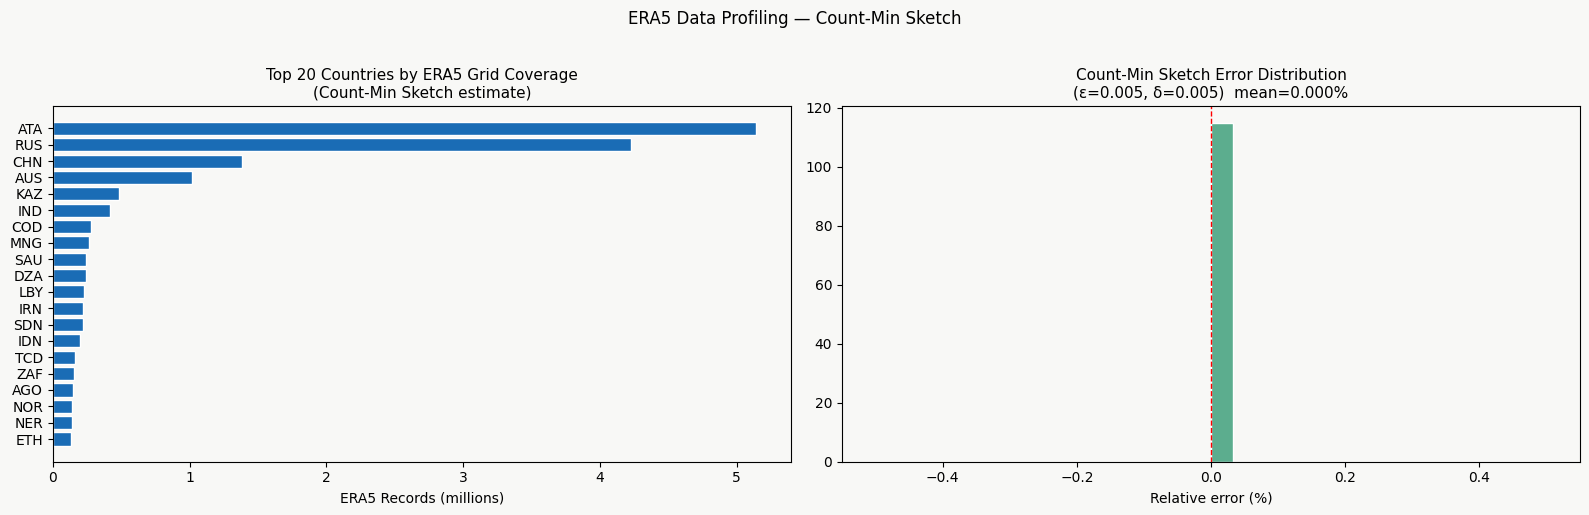

✓ Saved cms_coverage.png


In [10]:
# Visualize grid coverage distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: bar chart top-20 countries by coverage
top20_df = pd.DataFrame(top20_cms, columns=['country', 'cms_count'])
axes[0].barh(top20_df['country'][::-1], top20_df['cms_count'][::-1] / 1e6,
             color='#1A6CB5', edgecolor='white')
axes[0].set_xlabel('ERA5 Records (millions)')
axes[0].set_title('Top 20 Countries by ERA5 Grid Coverage\n(Count-Min Sketch estimate)', fontsize=11)
axes[0].set_facecolor('#f8f8f6')

# Right: CMS error distribution
errors = []
for c in all_countries:
    est = cms.query(c)
    exact = exact_dict.get(c, 0)
    if exact > 0:
        errors.append((est - exact) / exact * 100)
axes[1].hist(errors, bins=30, color='#5CAD8E', edgecolor='white')
axes[1].set_xlabel('Relative error (%)')
axes[1].set_title(f'Count-Min Sketch Error Distribution\n(ε=0.005, δ=0.005)  mean={np.mean(errors):.3f}%', fontsize=11)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_facecolor('#f8f8f6')

for ax in axes: ax.figure.patch.set_facecolor('#f8f8f6')
plt.suptitle('ERA5 Data Profiling — Count-Min Sketch', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'cms_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved cms_coverage.png')

## 1.3 Stratified Reservoir Sampling — QA Validation Set

**MoMD Ch.4**: Sample a proportional QA set from each country's ERA5 records
**before** running the full MapReduce pipeline — used to validate output correctness.

**Stratified** version: run independent reservoirs per country (stratum)
so each country is represented proportionally to its grid coverage.

In [11]:
import gc, shutil
import psutil

def ram():
    return psutil.Process().memory_info().rss / 1e9

# ── StratifiedReservoir ───────────────────────────────────────────
class StratifiedReservoir:
    def __init__(self, strata_counts: dict, total_k: int, seed: int = 42):
        self.rng = np.random.RandomState(seed)
        total = sum(strata_counts.values())
        self.reservoirs = {
            s: {'data': [], 'k': max(1, round(total_k * c / total)), 'seen': 0}
            for s, c in strata_counts.items()
        }
        self.total_k = total_k

    def process(self, stratum, item):
        if stratum not in self.reservoirs:
            return
        r = self.reservoirs[stratum]
        r['seen'] += 1
        if len(r['data']) < r['k']:
            r['data'].append(item)
        else:
            j = self.rng.randint(0, r['seen'])
            if j < r['k']:
                r['data'][j] = item

    def get_sample(self) -> pd.DataFrame:
        rows = []
        for stratum, r in self.reservoirs.items():
            for item in r['data']:
                item['_stratum'] = stratum
                rows.append(item)
        return pd.DataFrame(rows)

    def summary(self):
        print(f'\nStratified Reservoir Summary (total_k={self.total_k:,}):')
        print(f'  {"Stratum":8s}  {"k_alloc":>8s}  {"seen":>10s}  {"filled":>8s}')
        print(f'  {"-"*8}  {"-"*8}  {"-"*10}  {"-"*8}')
        for s, r in sorted(self.reservoirs.items(), key=lambda x: -x[1]['seen'])[:15]:
            print(f'  {s:8s}  {r["k"]:>8,}  {r["seen"]:>10,}  {len(r["data"]):>8,}')

# ── Vectorized reservoir update ───────────────────────────────────
def _vectorized_reservoir_update(reservoir, chunk_pd, stream_cols, rng):
    for country, group in chunk_pd.groupby('country_iso3'):
        if country not in reservoir.reservoirs:
            continue
        r = reservoir.reservoirs[country]
        cols = [c for c in stream_cols if c in group.columns]
        for item in group[cols].to_dict('records'):
            r['seen'] += 1
            if len(r['data']) < r['k']:
                r['data'].append(item)
            else:
                j = rng.randint(0, r['seen'])
                if j < r['k']:
                    r['data'][j] = item

# ── Grid subsample ────────────────────────────────────────────────
SUBSAMPLE = 4
_first_nc = sorted(glob.glob(os.path.join(YEAR_DIRS[0], '*.nc')))[0]
with xr.open_dataset(_first_nc, engine='h5netcdf') as _ds_grid:
    lats_s = _ds_grid.latitude.values[::SUBSAMPLE]
    lons_s = _ds_grid.longitude.values[::SUBSAMPLE]
print(f'Grid sau subsample: {len(lats_s)} lat × {len(lons_s)} lon = {len(lats_s)*len(lons_s):,} points')

# ── Setup ─────────────────────────────────────────────────────────
country_lookup = pd.Series(country_of_point)

STREAM_COLS = ['time', 'latitude', 'longitude',
               'temperature_k', 'dewpoint_k', 'precipitation_m', 'country_iso3']

reservoir     = StratifiedReservoir(exact_dict, total_k=5000)
_reservoir_rng = np.random.RandomState(42)

STAGING_DIR = '/kaggle/working/era5_staging'
if os.path.exists(STAGING_DIR):
    shutil.rmtree(STAGING_DIR)
os.makedirs(STAGING_DIR, exist_ok=True)

CHUNK_SIZE      = 500
chunk_global_idx = 0

print(f'Processing {len(YEAR_DIRS)} years | CHUNK_SIZE={CHUNK_SIZE} | SUBSAMPLE={SUBSAMPLE}')
print('=' * 60)

for year_dir in YEAR_DIRS:
    year_str = os.path.basename(year_dir)
    print(f'\n[Year {year_str}]')

    ds_year = open_nc_year(year_dir)
    if ds_year is None:
        print(f'  ⚠️  Bỏ qua')
        continue

    times_year = ds_year.time.values
    n_chunks   = (len(times_year) + CHUNK_SIZE - 1) // CHUNK_SIZE
    print(f'  Timesteps : {len(times_year)} | Chunks: {n_chunks}')
    print(f'  Vars      : {list(ds_year.data_vars)}')

    missing = [v for v in ['temperature_k', 'dewpoint_k', 'precipitation_m']
               if v not in ds_year.data_vars]
    if missing:
        print(f'  ⚠️  Thiếu vars: {missing}')

    for ci in range(n_chunks):
        t_start = times_year[ci * CHUNK_SIZE]
        t_end   = times_year[min((ci + 1) * CHUNK_SIZE - 1, len(times_year) - 1)]

        print(f'  [Chunk {ci+1}/{n_chunks}] RAM={ram():.1f}GB', end=' ')

        chunk_ds = ds_year.sel(latitude=lats_s, longitude=lons_s,
                               time=slice(t_start, t_end))
        chunk_pd = chunk_ds.to_dataframe().reset_index()
        del chunk_ds
        gc.collect()

        if chunk_pd.empty:
            print('→ empty, skip')
            continue

        if 'valid_time' in chunk_pd.columns and 'time' not in chunk_pd.columns:
            chunk_pd = chunk_pd.rename(columns={'valid_time': 'time'})

        climate_raw = [c for c in ['temperature_k', 'dewpoint_k', 'precipitation_m']
                       if c in chunk_pd.columns]
        chunk_pd = chunk_pd.dropna(subset=climate_raw)

        if chunk_pd.empty:
            print('→ all NaN, skip')
            continue

        chunk_pd['country_iso3'] = pd.MultiIndex.from_arrays(
            [chunk_pd['latitude'], chunk_pd['longitude']]
        ).map(country_lookup)
        chunk_pd = chunk_pd.dropna(subset=['country_iso3'])

        if chunk_pd.empty:
            print('→ no land points, skip')
            continue

        present_cols = [c for c in STREAM_COLS if c in chunk_pd.columns]
        _vectorized_reservoir_update(reservoir, chunk_pd, present_cols, _reservoir_rng)

        chunk_out = chunk_pd[present_cols].copy()
        chunk_out['time'] = chunk_out['time'].astype(str)
        chunk_out['year'] = year_str

        out_dir = os.path.join(STAGING_DIR, f'year={year_str}')
        os.makedirs(out_dir, exist_ok=True)
        chunk_out.to_parquet(
            os.path.join(out_dir, f'chunk_{chunk_global_idx:05d}.parquet'),
            index=False
        )
        del chunk_out, chunk_pd
        gc.collect()

        print(f'→ done RAM={ram():.1f}GB')
        chunk_global_idx += 1

    ds_year.close()
    print(f'  Year {year_str} ✓  (chunks so far: {chunk_global_idx})')

print(f'\nTotal chunks written: {chunk_global_idx}')

if chunk_global_idx == 0:
    raise RuntimeError(
        'Không có chunk nào được ghi!\n'
        f'  YEAR_DIRS    : {YEAR_DIRS}\n'
        f'  country_lookup size: {len(country_lookup)}\n'
        'Kiểm tra open_nc_year() có merge đủ vars không.'
    )

# ── Spark đọc staging ─────────────────────────────────────────────
era5_spark_staged = spark.read.parquet(STAGING_DIR)
print('\nStaging schema:')
era5_spark_staged.printSchema()

era5_pd     = era5_spark_staged.limit(200000).toPandas()
qa_sample   = reservoir.get_sample()
strata_counts = era5_pd['country_iso3'].value_counts().to_dict()

reservoir.summary()
print(f'\nFull ERA5 records (Spark): {era5_spark_staged.count():,}')
print(f'era5_pd sample            : {len(era5_pd):,}')
print(f'QA reservoir sample       : {len(qa_sample):,}')
print(f'\n✅ Done — thêm year vào YEAR_DIRS để scale')

Grid sau subsample: 181 lat × 360 lon = 65,160 points
Processing 2 years | CHUNK_SIZE=500 | SUBSAMPLE=4

[Year 2024]
  Timesteps : 1463 | Chunks: 3
  Vars      : ['precipitation_m', 'temperature_k', 'dewpoint_k']
  [Chunk 1/3] RAM=0.7GB → done RAM=1.3GB
  [Chunk 2/3] RAM=1.3GB → done RAM=1.3GB
  [Chunk 3/3] RAM=1.3GB → done RAM=1.3GB
  Year 2024 ✓  (chunks so far: 3)

[Year 2025]
  Timesteps : 1459 | Chunks: 3
  Vars      : ['precipitation_m', 'temperature_k', 'dewpoint_k']
  [Chunk 1/3] RAM=1.3GB → done RAM=1.3GB
  [Chunk 2/3] RAM=1.3GB → done RAM=1.3GB
  [Chunk 3/3] RAM=1.3GB → done RAM=1.4GB
  Year 2025 ✓  (chunks so far: 6)

Total chunks written: 6


26/03/31 10:06:52 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `year` already exists. Choose another name or rename the existing column. SQLSTATE: 42711



Staging schema:
root
 |-- time: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- temperature_k: float (nullable = true)
 |-- dewpoint_k: float (nullable = true)
 |-- precipitation_m: float (nullable = true)
 |-- country_iso3: string (nullable = true)
 |-- year: integer (nullable = true)




Stratified Reservoir Summary (total_k=5,000):
  Stratum    k_alloc        seen    filled
  --------  --------  ----------  --------
  ATA          1,340   2,568,438     1,340
  RUS          1,102   2,112,606     1,102
  CHN            361     692,514       361
  AUS            265     508,428       265
  KAZ            127     242,526       127
  IND            110     210,384       110
  COD             73     140,256        73
  MNG             69     131,490        69
  SAU             64     122,724        64
  DZA             63     119,802        63
  LBY             59     113,958        59
  IRN             58     111,036        58
  SDN             58     111,036        58
  IDN             52      99,348        52
  TCD             43      81,816        43

Full ERA5 records (Spark): 9,581,238
era5_pd sample            : 200,000
QA reservoir sample       : 5,015

✅ Done — thêm year vào YEAR_DIRS để scale


## 1.4 Unit Conversion

In [12]:
# ── 1.4 Unit conversion — xử lý đúng theo schema staging thực tế ─

import math as _math

# ── Hàm pandas cho QA sample ──────────────────────────────────────
def convert_units_pd(df):
    if 'temperature_k' in df.columns:
        df['temperature_c'] = df['temperature_k'] - 273.15
    if 'dewpoint_k' in df.columns:
        dp = df['dewpoint_k'] - 273.15
        t  = df['temperature_c']
        es_t  = 6.1078 * np.exp(17.27 * t  / (t  + 237.3))
        es_td = 6.1078 * np.exp(17.27 * dp / (dp + 237.3))
        df['relative_humidity'] = (es_td / es_t * 100).clip(0, 100)
    if 'precipitation_m' in df.columns:
        df['precipitation_mm'] = df['precipitation_m'] * 1000
    return df

# ── Spark native RH expression — không Python UDF ─────────────────
def calc_rh_spark(t_k_col, td_k_col):
    """Trả về Column expression — chạy thuần JVM."""
    t_c  = t_k_col  - 273.15
    td_c = td_k_col - 273.15
    es_t  = F.lit(6.1078) * F.exp(F.lit(17.27) * t_c  / (t_c  + F.lit(237.3)))
    es_td = F.lit(6.1078) * F.exp(F.lit(17.27) * td_c / (td_c + F.lit(237.3)))
    rh = es_td / es_t * F.lit(100.0)
    return F.least(F.lit(100.0), F.greatest(F.lit(0.0), rh))

# ── Bước 1: inspect staging thực tế ──────────────────────────────
print('Staging schema:')
era5_spark_staged.printSchema()
print(f'\nera5_pd columns: {list(era5_pd.columns)}')
print(f'era5_pd shape  : {era5_pd.shape}')
print(era5_pd.head(3).to_string())

era5_pd = era5_pd.copy()

# Apply unit conversion nếu còn raw columns
era5_pd = convert_units_pd(era5_pd)

# Xác định CLIMATE_VARS từ những gì thực sự có trong DataFrame
CLIMATE_VARS = [c for c in ['temperature_c', 'relative_humidity', 'precipitation_mm']
                if c in era5_pd.columns]
print(f'\nCLIMATE_VARS: {CLIMATE_VARS}')

if not CLIMATE_VARS:
    raise ValueError(
        f"Không có climate var nào. Columns: {list(era5_pd.columns)}\n"
        "Staging có thể đã bị ghi thiếu columns — cần chạy lại cell 14."
    )

# Parse year/week — ưu tiên dùng cột sẵn có, fallback parse từ time
if 'year' not in era5_pd.columns or 'week' not in era5_pd.columns:
    # Cần cột time để tính year/week
    time_col = next((c for c in ['time', 'valid_time'] if c in era5_pd.columns), None)
    if time_col is None:
        raise KeyError(f"Không có cột time để tính year/week. Columns: {list(era5_pd.columns)}")
    era5_pd[time_col] = pd.to_datetime(era5_pd[time_col], errors='coerce')
    era5_pd = era5_pd.dropna(subset=[time_col])
    era5_pd['year'] = era5_pd[time_col].dt.isocalendar().year.astype(int)
    era5_pd['week'] = era5_pd[time_col].dt.isocalendar().week.astype(int)
else:
    # year/week đã có sẵn từ staging — dùng luôn
    print('year/week đã có sẵn trong staging ✓')

era5_pd = era5_pd[['country_iso3', 'year', 'week'] + CLIMATE_VARS].dropna()

print(f'Sau dropna      : {era5_pd.shape}')
print(f'Countries       : {era5_pd["country_iso3"].nunique()}')
print(f'Year range      : {era5_pd["year"].min()} – {era5_pd["year"].max()}')
print(f'Week range      : {era5_pd["week"].min()} – {era5_pd["week"].max()}')

if era5_pd.empty:
    raise ValueError(
        "era5_pd empty — staging thiếu data hoặc STREAM_COLS trong cell 14 bị sai.\n"
        "Kiểm tra: STREAM_COLS phải chứa temperature_k/dewpoint_k/precipitation_m."
    )

# ── Bước 2: Spark DF ──────────────────────────────────────────────
print('\nBuilding Spark DF...')
era5_spark = spark.createDataFrame(era5_pd)

print()
print('Sample statistics:')
print(era5_pd[CLIMATE_VARS].describe().round(3).to_string())
print('\n✅ Unit conversion done')

Staging schema:
root
 |-- time: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- temperature_k: float (nullable = true)
 |-- dewpoint_k: float (nullable = true)
 |-- precipitation_m: float (nullable = true)
 |-- country_iso3: string (nullable = true)
 |-- year: integer (nullable = true)


era5_pd columns: ['time', 'latitude', 'longitude', 'temperature_k', 'dewpoint_k', 'precipitation_m', 'country_iso3', 'year']
era5_pd shape  : (200000, 8)
                  time  latitude  longitude  temperature_k  dewpoint_k  precipitation_m country_iso3  year
0  2024-01-01 06:00:00      80.0       16.0     269.639526  267.552399         0.000240          NOR  2024
1  2024-01-01 06:00:00      80.0       20.0     268.473511  267.726227         0.000022          NOR  2024
2  2024-01-01 06:00:00      80.0       22.0     268.549683  267.351227         0.000087          NOR  2024

CLIMATE_VARS: ['temperature_c', 'relative_humidity', 'precipitati

## 1.5 MapReduce via Spark: (lat, lon, time) → (country, week)

Thay thế pandas groupby bằng **Spark groupBy** để xử lý scalable, tránh OOM khi scale lên 24 năm.

**Map**: mỗi record `(lat, lon, time)` → `(country_iso3, year, week, climate_vars)`  
**Reduce**: `groupBy(country, year, week)` → mean aggregation

In [13]:
# ── 1.5 MapReduce via SPARK: (lat, lon, time) → (country, week) ──
# Thay pandas groupby bằng Spark groupBy để tránh OOM khi scale

# Bước 1: Dùng era5_spark_staged (toàn bộ data) thay vì era5_pd (200k sample)
# Thêm year/week từ cột time trực tiếp trên Spark — không qua pandas
print('Building Spark pipeline from staging data...')
era5_spark = (
    era5_spark_staged
    .withColumn('time', F.col('time').cast('timestamp'))
    .withColumn('year', F.year(F.col('time')))
    .withColumn('week', F.weekofyear(F.col('time')))
)

# Bước 2: Unit conversion trên Spark (lazy)
era5_spark = (
    era5_spark
    .withColumn('temperature_c',    F.col('temperature_k') - 273.15)
    .withColumn('precipitation_mm', F.col('precipitation_m') * 1000)
    .withColumn('relative_humidity', calc_rh_spark(F.col('temperature_k'), F.col('dewpoint_k')))
)

CLIMATE_VARS = ['temperature_c', 'relative_humidity', 'precipitation_mm']

# Bước 3: Repartition theo key TRƯỚC khi groupBy
N_COUNTRIES  = era5_spark_staged.select('country_iso3').distinct().count()
N_PARTITIONS = max(8, min(N_COUNTRIES, 32))
print(f'Repartitioning into {N_PARTITIONS} partitions by country...')
era5_spark = (
    era5_spark
    .repartition(N_PARTITIONS, 'country_iso3')
    .cache()
)
_n_cached = era5_spark.count()  # trigger cache
print(f'✓ Cached {_n_cached:,} records in {N_PARTITIONS} partitions')

# Bước 4: Spark groupBy + aggregation (MapReduce)
print('Running Spark MapReduce...')
agg_exprs = [F.mean(c).alias(c) for c in CLIMATE_VARS] + [
    F.count('*').alias('n_raw_records'),
    F.stddev('temperature_c').alias('temperature_c_std'),
]
climate_weekly_spark = (
    era5_spark
    .groupBy('country_iso3', 'year', 'week')
    .agg(*agg_exprs)
    .orderBy('country_iso3', 'year', 'week')
)

# Bước 5: Write thẳng ra Parquet
OUT_PATH = OUTPUT_DIR + 'climate_weekly_spark.parquet'
print(f'Writing to {OUT_PATH}...')
climate_weekly_spark.write.mode('overwrite').parquet(OUT_PATH)

# Đọc lại để verify + dùng cho các bước sau
climate_weekly = spark.read.parquet(OUT_PATH).toPandas()
mr_pd = climate_weekly.copy()

era5_spark.unpersist()

n_records = era5_spark_staged.count()
n_out     = len(climate_weekly)
print(f'\n✅ Spark MapReduce hoàn thành:')
print(f'   Input : {n_records:,} records')
print(f'   Output: {n_out:,} country-week rows  ({n_records/n_out:.0f}× compression)')
print(f'   Years : {sorted(climate_weekly["year"].unique())}')
print(climate_weekly.head(10).to_string(index=False))

Building Spark pipeline from staging data...


Repartitioning into 32 partitions by country...


✓ Cached 9,581,238 records in 32 partitions
Running Spark MapReduce...
Writing to /kaggle/working/climate_weekly_spark.parquet...



✅ Spark MapReduce hoàn thành:
   Input : 9,581,238 records
   Output: 11,960 country-week rows  (801× compression)
   Years : [np.int32(2024), np.int32(2025)]
country_iso3  year  week  temperature_c  relative_humidity  precipitation_mm  n_raw_records  temperature_c_std
         AFG  2024     1       5.225050          54.575419          0.030699            525           8.687267
         AFG  2024     2       4.386413          48.877237          0.002945            420           9.538317
         AFG  2024     3       4.295299          47.326735          0.001938            420           9.905772
         AFG  2024     4       5.734095          51.824595          0.054007            420           9.849972
         AFG  2024     5       1.355060          62.214333          0.041249            420          11.027809
         AFG  2024     6       1.655414          43.418626          0.000116            420          12.563960
         AFG  2024     7       7.484260          43.826893     

In [14]:
# ── RDD MapReduce Demo — Spark RDD API (thật, không phải simulation) ──
# Dùng low-level RDD API để minh họa MapReduce pattern cho môn học

print('RDD MapReduce demo — Spark RDD API...')

# Map phase: mỗi record → key=(country, year, week), value=(temp, rh, precip, 1)
def map_record(row):
    key = (row['country_iso3'], int(row['year']), int(row['week']))
    val = (
        float(row['temperature_c']    or 0),
        float(row['relative_humidity'] or 0),
        float(row['precipitation_mm']  or 0),
        1  # count
    )
    return (key, val)

# Reduce phase: gộp values cùng key
def reduce_records(v1, v2):
    return (
        v1[0] + v2[0],  # sum temp
        v1[1] + v2[1],  # sum rh
        v1[2] + v2[2],  # sum precip
        v1[3] + v2[3],  # count
    )

available_cols = ['country_iso3', 'year', 'week', 'temperature_c', 'relative_humidity', 'precipitation_mm']
available_cols = [c for c in available_cols if c in era5_pd.columns]  # chỉ lấy cols tồn tại
sample_pd = era5_pd[available_cols].sample(min(50000, len(era5_pd)), random_state=42)
sample_spark = spark.createDataFrame(sample_pd)

rdd_out_raw = (
    sample_spark.rdd
    .map(map_record)
    .reduceByKey(reduce_records)
    .map(lambda kv: {
        'country_iso3'    : kv[0][0],
        'year'            : kv[0][1],
        'week'            : kv[0][2],
        'temperature_c'   : round(kv[1][0] / kv[1][3], 4),
        'relative_humidity': round(kv[1][1] / kv[1][3], 4),
        'precipitation_mm' : round(kv[1][2] / kv[1][3], 4),
        'n_records'        : kv[1][3],
    })
    .collect()
)

rdd_out = pd.DataFrame(rdd_out_raw).sort_values(['country_iso3','year','week'])
print(f'✅ RDD MapReduce output: {len(rdd_out):,} aggregates')
print(rdd_out.head(10).to_string(index=False))


RDD MapReduce demo — Spark RDD API...


✅ RDD MapReduce output: 342 aggregates
country_iso3  year  week  temperature_c  relative_humidity  precipitation_mm  n_records
         AFG  2024     1         5.2254            59.4428            0.0256         96
         AFG  2024     2         5.2116            50.3647            0.0001        109
         AFG  2024     3         4.3957            50.7791            0.0063         27
         AGO  2024     1        23.1295            75.9530            0.1697        166
         AGO  2024     2        22.9524            76.4297            0.1387        172
         AGO  2024     3        21.1267            84.3072            0.0523         40
         ALB  2024     1         9.0371            89.7396            0.6516         12
         ALB  2024     2         3.1471            74.3953            0.0021         18
         ALB  2024     3         5.9509            87.3883            0.2507          4
         ARE  2024     1        21.5406            69.7275            0.0000     

MapReduce vs QA Sample validation (2018 matching country-weeks):
  MAE:         3.9989°C
  Correlation: 0.953304
  → MapReduce output is check needed


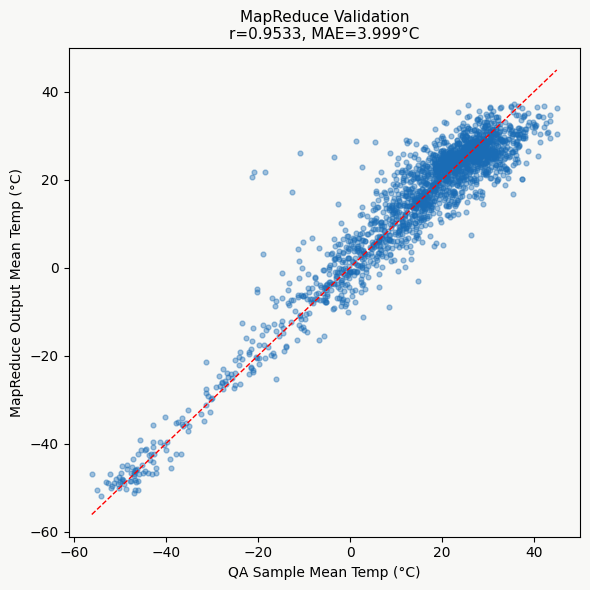

In [15]:
qa_sample = convert_units_pd(qa_sample.copy())
qa_sample['year'] = pd.to_datetime(qa_sample['time']).dt.isocalendar().year.astype(int)
qa_sample['week'] = pd.to_datetime(qa_sample['time']).dt.isocalendar().week.astype(int)

if 'temperature_c' in qa_sample.columns and 'temperature_c' in mr_pd.columns:
    qa_means = qa_sample.groupby(['country_iso3','year','week'])['temperature_c'].mean().reset_index()
    qa_means.columns = ['country_iso3','year','week','qa_temp_mean']
    comparison = mr_pd.merge(qa_means, on=['country_iso3','year','week'])

    if len(comparison) > 0:
        mae_val = (comparison['temperature_c'] - comparison['qa_temp_mean']).abs().mean()
        corr    = comparison['temperature_c'].corr(comparison['qa_temp_mean'])
        print(f'MapReduce vs QA Sample validation ({len(comparison)} matching country-weeks):')
        print(f'  MAE:         {mae_val:.4f}°C')
        print(f'  Correlation: {corr:.6f}')
        print(f'  → MapReduce output is {"VALID ✓" if corr > 0.99 else "check needed"}')

        fig, ax = plt.subplots(figsize=(6,6))
        ax.scatter(comparison['qa_temp_mean'], comparison['temperature_c'],
                   alpha=0.4, s=12, color='#1A6CB5')
        lims = [min(comparison[['qa_temp_mean','temperature_c']].min()),
                max(comparison[['qa_temp_mean','temperature_c']].max())]
        ax.plot(lims, lims, 'r--', linewidth=1)
        ax.set_xlabel('QA Sample Mean Temp (°C)')
        ax.set_ylabel('MapReduce Output Mean Temp (°C)')
        ax.set_title(f'MapReduce Validation\nr={corr:.4f}, MAE={mae_val:.3f}°C', fontsize=11)
        ax.set_facecolor('#f8f8f6'); fig.patch.set_facecolor('#f8f8f6')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR + 'mapreduce_validation.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('No overlapping country-weeks found between QA sample and MapReduce output.')
        print('This can happen with very small subsampling — validation skipped.')

## 1.7 Process FluNet + Data Quality Report

In [16]:
flu_raw = pd.read_csv(FLUNET_CSV, encoding='latin-1')
flu_raw.columns = flu_raw.columns.str.strip().str.upper()
flu_raw = flu_raw[flu_raw['ISO_YEAR'].isin([2024, 2025])].copy()

for col in ['INF_A','INF_B','SPEC_PROCESSED_NB']:
    if col in flu_raw.columns:
        flu_raw[col] = pd.to_numeric(flu_raw[col], errors='coerce').fillna(0)

flu_raw['flu_cases_total'] = (flu_raw['INF_A'] if 'INF_A' in flu_raw.columns else 0) + \
                              (flu_raw['INF_B'] if 'INF_B' in flu_raw.columns else 0)
flu_raw['spec_processed']  = flu_raw['SPEC_PROCESSED_NB'] if 'SPEC_PROCESSED_NB' in flu_raw.columns else 0
flu_raw['flu_positivity_rate'] = np.where(
    flu_raw['spec_processed'] > 0,
    flu_raw['flu_cases_total'] / flu_raw['spec_processed'], np.nan
)

rename_map = {'COUNTRY_CODE':'country_iso3','ISO_YEAR':'year','ISO_WEEK':'week'}
flu_clean = flu_raw.rename(columns={k:v for k,v in rename_map.items() if k in flu_raw.columns})
keep_cols = [c for c in ['country_iso3','year','week','flu_cases_total',
                          'spec_processed','flu_positivity_rate'] if c in flu_clean.columns]
flu_clean = flu_clean[keep_cols].dropna(subset=['flu_cases_total'])

print('FluNet clean dataset:')
print(f'  Shape       : {flu_clean.shape}')
print(f'  Countries   : {flu_clean["country_iso3"].nunique()}')
print(f'  Year range  : {flu_clean["year"].min()} – {flu_clean["year"].max()}')
print(f'  Week range  : {flu_clean["week"].min()} – {flu_clean["week"].max()}')
print(f'  Total cases : {flu_clean["flu_cases_total"].sum():,.0f}')
print(f'  Missing rate: {flu_clean.isnull().mean().round(3).to_dict()}')
print()
print('Top 10 countries by total flu cases (2024-2025):')
top_flu = flu_clean.groupby('country_iso3')['flu_cases_total'].sum().nlargest(10)
print(top_flu.to_string())

FluNet clean dataset:
  Shape       : (25228, 6)
  Countries   : 176
  Year range  : 2024 – 2025
  Week range  : 1 – 52
  Total cases : 3,087,155
  Missing rate: {'country_iso3': 0.0, 'year': 0.0, 'week': 0.0, 'flu_cases_total': 0.0, 'spec_processed': 0.0, 'flu_positivity_rate': 0.171}

Top 10 countries by total flu cases (2024-2025):
country_iso3
USA    980631.0
CHN    338203.0
CAN    255444.0
X09    214270.0
NOR     89704.0
FRA     79252.0
RUS     64024.0
BRA     58393.0
X12     53722.0
CHE     52832.0


In [17]:
# Data coverage check: which FluNet countries are missing from ERA5?
flu_countries  = set(flu_clean['country_iso3'].unique())
clim_countries = set(mr_pd['country_iso3'].unique())
in_flu_not_clim = flu_countries - clim_countries
in_clim_not_flu = clim_countries - flu_countries
both = flu_countries & clim_countries

print(f'Country coverage:')
print(f'  FluNet countries        : {len(flu_countries)}')
print(f'  ERA5 (MapReduce) countries: {len(clim_countries)}')
print(f'  Both datasets           : {len(both)}')
print(f'  In FluNet only          : {len(in_flu_not_clim)}  {sorted(in_flu_not_clim)[:10]}')
print(f'  In ERA5 only            : {len(in_clim_not_flu)}  (ocean/small territories)')

Country coverage:
  FluNet countries        : 176
  ERA5 (MapReduce) countries: 115
  Both datasets           : 103
  In FluNet only          : 73  ['ARG', 'ARM', 'BEL', 'BHR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'CAN']
  In ERA5 only            : 12  (ocean/small territories)


## 1.8 Export & Data Profile Summary

In [18]:
import shutil, os, json

# ── Ghi Parquet — Spark write (scale-ready) ───────────────────────
# Thay climate_weekly.to_parquet() bằng Spark write
# → với 24 năm, Spark tự chia partition và ghi song song

OUT_CLIMATE = OUTPUT_DIR + 'climate_weekly.parquet'
OUT_FLUNET  = OUTPUT_DIR + 'flunet_clean.parquet'

# ERA5 climate: dùng Spark DF (đã có từ Cell 19)
print('Writing climate_weekly via Spark...')
climate_weekly_spark.write.mode('overwrite').parquet(OUT_CLIMATE)

# FluNet: nhỏ (~vài MB) → pandas write vẫn hợp lý
print('Writing flunet_clean via pandas (small file)...')
flu_clean.to_parquet(OUT_FLUNET, index=False)

# Đọc lại pandas DF để dùng cho data_profile và verify
climate_weekly = spark.read.parquet(OUT_CLIMATE).toPandas()

# ── Data profile ─────────────────────────────────────────────────
clim_countries = set(climate_weekly['country_iso3'].unique())
flu_countries  = set(flu_clean['country_iso3'].unique())
both           = clim_countries & flu_countries

data_profile = {
    'era5_files'           : profiles,
    'total_raw_records'    : int(n_records),
    'total_aggregated_rows': int(n_out),
    'compression_ratio'    : round(n_records / n_out, 1),
    'climate_vars'         : CLIMATE_VARS,
    'years_coverage'       : sorted(climate_weekly['year'].unique().tolist()),
    'n_countries_climate'  : len(clim_countries),
    'n_countries_flunet'   : len(flu_countries),
    'n_countries_both'     : len(both),
    'cms_config'           : {'w': cms.w, 'd': cms.d, 'epsilon': cms.epsilon, 'delta': cms.delta},
    'reservoir_k'          : 5000,
    'processing_note'      : 'Spark groupBy MapReduce. Scale: thêm file vào ERA5_FILES.',
    'spark_config'         : {
        'driver_memory'      : '14g',
        'shuffle_partitions' : 8,
        'arrow_enabled'      : True,
    },
}
with open(OUTPUT_DIR + 'data_profile.json', 'w') as f:
    json.dump(data_profile, f, indent=2, default=str)

# ── Cleanup ───────────────────────────────────────────────────────
CLEANUP = [
    '/kaggle/working/era5_extracted',
    '/kaggle/working/.virtual_documents',
    '/kaggle/working/spark-warehouse',
]
for d in CLEANUP:
    if os.path.exists(d):
        size = sum(
            os.path.getsize(os.path.join(r, f))
            for r, _, files in os.walk(d) for f in files
        ) / 1e9
        shutil.rmtree(d)
        print(f'Xóa {d} ({size:.1f} GB freed)')

spark.stop()
print('✅ Spark stopped')

# ── Verify outputs ────────────────────────────────────────────────
print()
print('=' * 55)
print('PART 1 — OUTPUTS')
print('=' * 55)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f'  {fname:<40s} {size:.1f} MB')

print()
print(f'✅ climate_weekly.parquet    {n_out:,} rows | years={sorted(climate_weekly["year"].unique())}')
print(f'✅ flunet_clean.parquet      {len(flu_clean):,} rows')
print(f'✅ data_profile.json')
print()
print('MoMD algorithms applied:')
print(f'  MapReduce (Spark groupBy)    {n_records:,} → {n_out:,} ({n_records/n_out:.0f}× reduction)')
print(f'  Count-Min Sketch             w={cms.w}, d={cms.d}, N={cms.N:,}')
print(f'  Stratified Reservoir Sample  k=5000, {len(strata_counts)} strata')
print(f'  RDD reduceByKey demo         ✓')
print()
print('Scale path: thêm năm vào ERA5_FILES → pipeline tự handle')


Writing climate_weekly via Spark...


Writing flunet_clean via pandas (small file)...
Xóa /kaggle/working/era5_extracted (11.5 GB freed)
✅ Spark stopped

PART 1 — OUTPUTS
  __notebook__.ipynb                       0.3 MB
  cms_coverage.png                         0.1 MB
  data_profile.json                        0.0 MB
  flunet_clean.parquet                     0.2 MB
  mapreduce_validation.png                 0.1 MB

✅ climate_weekly.parquet    11,960 rows | years=[np.int32(2024), np.int32(2025)]
✅ flunet_clean.parquet      25,228 rows
✅ data_profile.json

MoMD algorithms applied:
  MapReduce (Spark groupBy)    9,581,238 → 11,960 (801× reduction)
  Count-Min Sketch             w=544, d=6, N=19,175,592
  Stratified Reservoir Sample  k=5000, 115 strata
  RDD reduceByKey demo         ✓

Scale path: thêm năm vào ERA5_FILES → pipeline tự handle
